<a href="https://colab.research.google.com/github/pc-repo/algorytmy-ewolucyjne/blob/main/AE_K8_65456.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AE_K8**
Algorytmy ewolucyjne - projekt na zajęciach

###**Zad. 1.** Korzystając z biblioteki **geneticalgorithm** napisz program w *Python* implementujący algorytm ewolucyjny do znajdowania minimalnej sumarycznej długości spawów pojemnika w kształcie walca wykonanego z blachy przy założeniu, że pojemność walca nie może znacząco róznić się od 2 m3. W tym zadaniu nie formułuj wniosków!
$\color{red}{Uwaga:}$
### Pamiętaj, że jeśli proces optymalizacji będzie wymagał czasu, to możesz zająć się przygotowaniem skryptów lub odpowiedzi do następnego zadania.

Założenie wstępne - walec ma tylko dno oraz z "jednej strony" jest spaw przez całą długość. Zastosowanie mają wzory na objętość walca oraz obwód.

V = π * r^2 * h         ==>>  objętość walca

L = h + 2 * π * r       ==>>  długość spawu (bok + dno)

Minimalizujemy L, natomiast V uwzględniamy w członie kary (X). Jest to  zagadadnienie dwu wymiarowe.

Niewiadome to r i h.



Definicja funkcji celu. Względem poszukiwanych wartości r oraz h wyznaczamy długość spawu oraz objętość walca z zamiarem znalezienia miminum zagadnienia. Na podstawie objętości wyznaczamy wyrażenie kary, które pogarsza wynik (stąd z wartością dodatnią - szukamy minimu). Gotowa funkcja celu zwraca sumę szukanej długości plus człon kary ( L + X).

In [ ]:
def funkcja_celu(x):
  r = x[0]
  h = x[1]

  # DŁugość spawu
  L = h + 2 * np.pi * r

  # Objętość walca
  V = np.pi * r**2 * h

  # Człon kary
  X = (V - 2)**2

  return L + X

Wymiar zagadnienia - narzut na granice, odpowiednio r[0]-> 0.1 do 5.0 oraz r[1] -> 0.1 do 10.0. Tablica dwuwymiarowa przypisana do bound.

In [ ]:
bound = np.array([[0.1, 5.0], [0.1, 10.0]]) # Zakres dla wysokości i promienia

Użyłem domyślnych wartości z podpowiedzi Jupytera. Krzyżowanie jednorodne, selekcja ruletkowa, reszta opisu w kodzie poniżej.

In [ ]:
# Parametry algorytmu ewolucyjnego:

param = {
  'max_num_iteration': 1000,        # Max liczba iteracji
  'population_size': 100,           # Rozmiar populacji
  'mutation_probability': 0.01,     # Prawdopodobieństwo mutacji
  'elit_ratio': 0.01,               # Ilość jedn. elitarnych
  'crossover_probability': 0.8,     # Prawdopodobieństwo krzyżowania
  'parents_portion': 0.3,           # Ilość rodziców mogących dać potomka
  'crossover_type': 'uniform',      # Krzyżowanie jednolite
  'max_iteration_without_improv': 100,      # Max ilość iteracji bez poprawy wartości
  'selection_type': 'roulette',     # Selekcja ruletkowa
  'display': False                  # Blokda komentarz algorytmu
}


 The best solution found:
 [0.53181172 1.65148451]

 Objective function:
 5.276648835051378


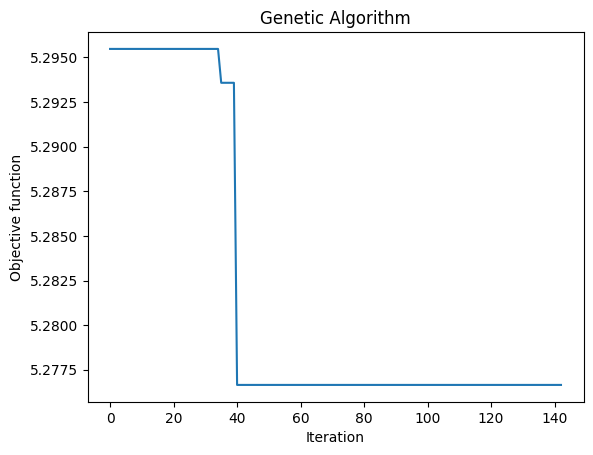

In [ ]:
model = ga(function=funkcja_celu,           # funkcja celu
           dimension=2,                     # wymiar zagadnienia
           variable_type='real',            # typ zagadnienia
           variable_boundaries=bound,       # zakres wartości zagadnienia
           algorithm_parameters=param)      # Prametry algorytmu (jak powyżej)

model.run()                                 # Uruchomuenie modelu

Poniżej wyniki optymalizacji - długość spawu, promień, wysokość, osiągnięta objętość.

In [ ]:
# Wyniki
best_solution = model.best_variable
best_fitness = model.best_function

r_optim = best_solution[0]
h_optim = best_solution[1]
length = h_optim + 2 * np.pi * r_optim
volume = np.pi * r_optim**2 * h_optim

print("\n--- Wyniki optymalizacji ---")
print(f"Wyznaczony promień (r): {r_optim:.4f} m")
print(f"Wyznaczona wysokość (h): {h_optim:.4f} m")
print(f"Długość spawów: {length:.4f} m")
print(f"Objętość walca: {volume:.4f} m^3 (docelowo 2 m^3)")
print(f"Funkcji celu (długość spawów + kara): {best_fitness:.4f}")


--- Wyniki optymalizacji ---
Optymalny promień (r): 0.5318 m
Optymalna wysokość (h): 1.6515 m
Szacowana minimalna długość spawów: 4.9930 m
Obliczona objętość walca: 1.4674 m^3 (docelowo 2 m^3)
Najlepsza wartość funkcji celu (długość spawów + kara): 5.2766


### **Zad 2.** Przeprowadź 20 eksperynetów i na wykresie przedstaw długości spawów dla każdego z nich. Przedstaw strategię zastosowaną w Zad. 1. i wnioski dotyczące Zad. 1. i Zad. 2.

###**Zad. 3.** Korzystając z biblioteki *geneticalgorithm* napisz program w *Python* implementujący algorytm ewolucyjny do znajdowania minimum funkcji *tricky_sin* (zedfiniowanej i opisanej poniżej) dla $x \in [-1, 2].\quad$
### Zobrazuj wyniki w postaci list i wykresów dla wielu uruchomień AE. Opis zatosowanej strategii i wnioski przedstawisz w kolejnym zadaniu!

### Funkcja jest zdefiniowana jako:
$f(x) = x \cdot \sin(10 \pi x) + 1$

Poniżej poglądowo wykres funkcji z zadania. Minimum jest dla wartości argumentu ok 1.9 - szacunkowo

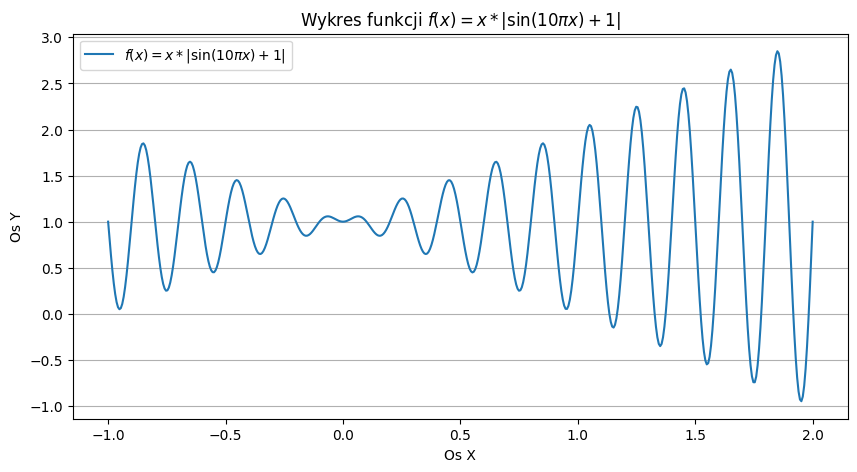

In [ ]:
from matplotlib import pyplot as plt

def f(x):
    return x*np.sin(10*np.pi*x)+1

# Wektor wejciowy (dziedzina) i obliczony wyjciowy (wartości funkcji)
x_values = np.linspace(-1, 2, 500)
y_values = f(x_values)

# Rysowanie
plt.figure(figsize=(10, 5))
plt.plot(x_values, y_values, label=r'$f(x) = x * |\sin(10πx) +1 |$')
plt.xlabel('Os X')
plt.ylabel('Os Y')
plt.title('Wykres funkcji $f(x) = x * |\sin(10πx) +1 |$')
plt.grid(axis = 'y')
plt.legend()
plt.show()

potrzebna biblioteka oraz importy

In [ ]:
!pip install geneticalgorithm

import numpy as np
from geneticalgorithm import geneticalgorithm as ga

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for func-timeout: filename=func_timeout-4.3.5-py3-none-any.whl size=15077 sha256=547eddd80aec88641d4b8c550e2ef45f8a8d696f8d7524feb7367ccab00c567f
  Stored in directory: /root/.cache/pip/wheels/07/e6/86/f23164d12c3134966614102db8e7956ab359faf7ffd78703ce
Successfully built func-timeout


Definicja funkcji (cel obliczeń algorytmu)

In [ ]:
def tricky_sin(x):
  return x*np.sin(10*np.pi*x)+1

In [ ]:
# Określnie przestrzeni zagadnienia
bound = np.array([[-1.0, 2.0]])

# Określenie typu przechowywanych wartości - tu 4D float
typex = np.array([['real']])

# Ilość pętli głównego algorytmu
runs = 2

definicje zmiennych przechowywania wyniku

In [ ]:
result = []
best_solutions = []
best_fitness_values = []

Parametry - identyczne jak w zadaniu 1. Tu już nie opisuję

In [ ]:
param = {
  'max_num_iteration': 1000,
  'population_size': 100,
  'mutation_probability': 0.01,
  'elit_ratio': 0.01,
  'crossover_probability': 0.8,
  'parents_portion': 0.3,
  'crossover_type': 'uniform',
  'max_iteration_without_improv': 100,
  'selection_type': 'roulette',
  'display': False
}


Odtworzenie algorytmu w pętli - "runs"razy


--- Uruchomienie 1/2 ---
 The best solution found:
 [1.94525708]

 Objective function:
 -0.9237027329872554


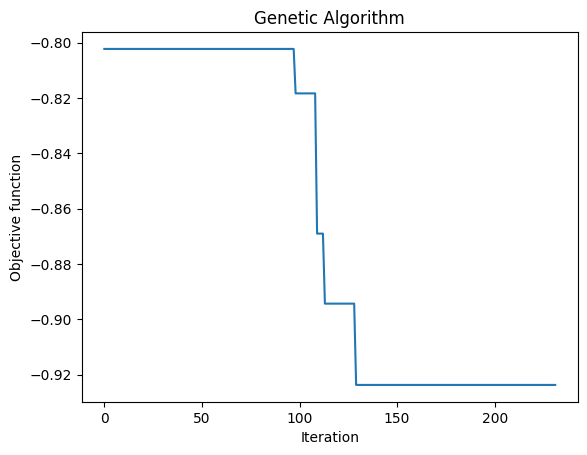


Wartość funkcji w tym punkcie: -0.9237027329872554

--- Uruchomienie 2/2 ---
 The best solution found:
 [1.95645064]

 Objective function:
 -0.9164140192556969


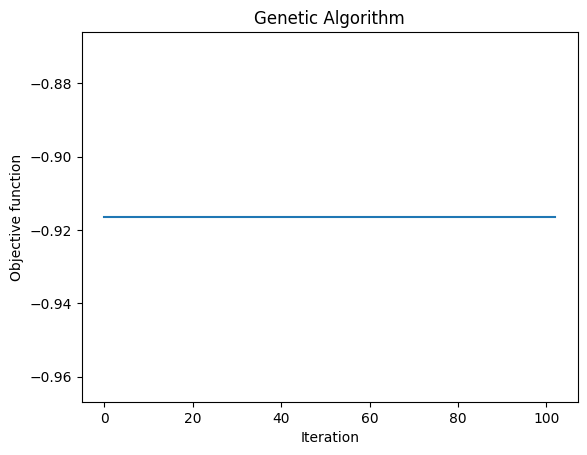


Wartość funkcji w tym punkcie: -0.9164140192556969


In [ ]:
for i in range(runs):
    print(f"\n--- Uruchomienie {i+1}/{runs} ---")
    model = ga(function=tricky_sin,
               dimension=1,
               variable_boundaries=bound,
               variable_type='real',
               function_timeout=10, # Zabezpieczenie przed zbyt długim działaniem funkcji
               algorithm_parameters= param
               )

    model.run()

    result.append(model.output_dict)
    best_solutions.append(model.output_dict['variable'])
    best_fitness_values.append(model.output_dict['function'])
    print(f"Najlepsze znalezione x: {model.output_dict['variable']}")
    print(f"Wartość funkcji w tym punkcie: {model.output_dict['function']}")

Kolejne wyniki

In [ ]:
for i, (zad, wart) in enumerate(zip(best_solutions, best_fitness_values)):
    print(f"Uruchomienie {i+1}: x = {zad[0]:.6f}, f(x) = {wart:.6f}")

Uruchomienie 1: x = 1.954491, f(x) = -0.935072
Uruchomienie 2: x = 1.950251, f(x) = -0.950190
Uruchomienie 3: x = 1.939155, f(x) = -0.827693
Uruchomienie 4: x = 1.738169, f(x) = -0.619493
Uruchomienie 5: x = 1.945257, f(x) = -0.923703
Uruchomienie 6: x = 1.956451, f(x) = -0.916414


Zmieniająca się w historii wartość funkcji.

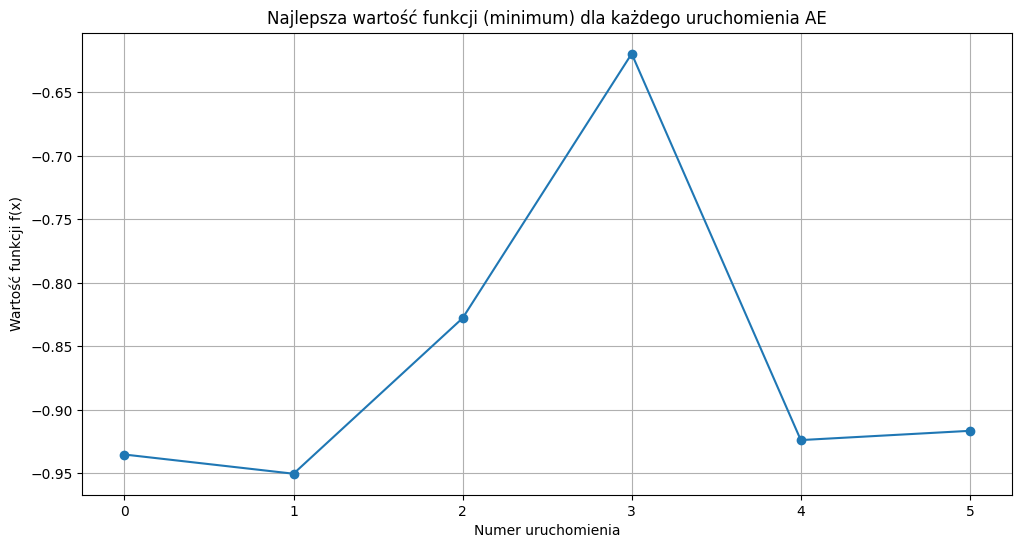

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(best_fitness_values, 'o-')
plt.title('Najlepsza wartość funkcji (minimum) dla każdego uruchomienia AE')
plt.xlabel('Numer uruchomienia')
plt.ylabel('Wartość funkcji f(x)')
plt.grid(True)
plt.show()

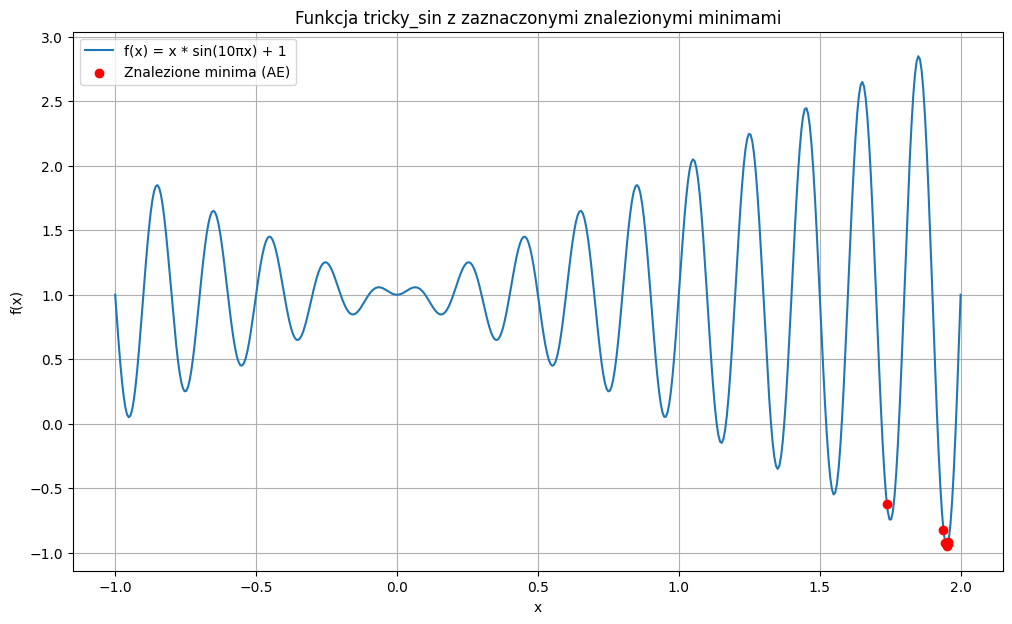

In [ ]:
x_values = np.linspace(-1, 2, 500)
y_values = tricky_sin(x_values)

plt.figure(figsize=(12, 7))
plt.plot(x_values, y_values, label='f(x) = x * sin(10πx) + 1')
plt.scatter(np.array(best_solutions).flatten(), best_fitness_values, color='red', zorder=5, label='Znalezione minima (AE)')
plt.title('Funkcja tricky_sin z zaznaczonymi znalezionymi minimami')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Ocena efektów kształcenia
for i in range(3):
    razem_pr = punkty[i]/Max[i]
    print(f"Efekt U{i+1} | Ocena: {przelicz(razem_pr)} | {punkty[i]} pkt.")

Efekt U1 | Ocena: 5 | 20 pkt.
Efekt U2 | Ocena: 5 | 20 pkt.
Efekt U3 | Ocena: 5 | 20 pkt.


In [ ]:
# Ocena kolokwium:
razem=0
maximum = 0

for i in range(3):
  razem += punkty[i]
  maximum += Max[i]

print(f"Ocena: {przelicz(razem/maximum)} | {razem} pkt. | {razem/maximum*100} %")

Ocena: 5 | 60 pkt. | 100.0 %
